# Multimodal Conv Benchmark — Evaluation Analysis

7 models · 200 items each · 2 taxonomies · 3 question types

**Step 1**: filter the 68 multiple-choice items missing A/B/C/D options (unanswerable as posed).

In [1]:
import json, re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130})

EVAL_DIR = Path('/projects/bfuj/lzhang49/multimodal-conv-bench/eval_results')
MC_OPTION_RE = re.compile(r'\b[A-D][).]')

# Gemma family first (small → large), then Qwen (small → large)
MODEL_ORDER = [
    'gemma-4-E4B-it',
    'gemma-4-26B-A4B-it',
    'gemma-4-31B-it',
    'Qwen3.5-2B',
    'Qwen3.5-4B',
    'Qwen3.5-9B',
    'Qwen3.5-27B',
]
MODEL_COLORS = {
    'gemma-4-E4B-it':      '#f4a261',
    'gemma-4-26B-A4B-it':  '#e06c75',
    'gemma-4-31B-it':      '#922b21',
    'Qwen3.5-2B':          '#aec6e8',
    'Qwen3.5-4B':          '#6baed6',
    'Qwen3.5-9B':          '#3182bd',
    'Qwen3.5-27B':         '#08519c',
}

frames = []
for f in sorted(EVAL_DIR.glob('*.jsonl')):
    rows = [json.loads(l) for l in f.open() if l.strip()]
    d = pd.DataFrame(rows)
    d['model'] = d['eval_model'].str.split('/').str[-1]
    frames.append(d)
raw = pd.concat(frames, ignore_index=True)
print(f'Loaded {len(raw)} rows, {raw["model"].nunique()} models, {raw["idx"].nunique()} unique items')
print(raw.groupby("model")["correct"].agg(["mean","count"]).assign(mean=lambda x: x["mean"]*100).reindex(MODEL_ORDER).round(1))

Loaded 1400 rows, 7 models, 200 unique items
                    mean  count
model                          
gemma-4-E4B-it      54.0    200
gemma-4-26B-A4B-it  61.5    200
gemma-4-31B-it      57.5    200
Qwen3.5-2B          60.5    200
Qwen3.5-4B          57.0    200
Qwen3.5-9B          54.0    200
Qwen3.5-27B         52.5    200


## 1. Filter: Remove MC Questions Missing A/B/C/D Options

In [2]:
raw['has_options'] = raw['question'].apply(lambda q: bool(MC_OPTION_RE.search(q or '')))

one = raw[raw['model'] == raw['model'].iloc[0]]
mc_total = (one['question_type'] == 'multiple_choice').sum()
mc_bad   = ((one['question_type'] == 'multiple_choice') & ~one['has_options']).sum()

print(f'Items per model        : {len(one)}')
print(f'Multiple-choice total  : {mc_total}')
print(f'  missing options (BAD): {mc_bad}  → dropped')
print(f'  with options  (GOOD) : {mc_total - mc_bad}  → kept')
print(f'yes_no items           : {(one["question_type"]=="yes_no").sum()}')
print(f'count items            : {(one["question_type"]=="count").sum()}')

df = raw[raw['has_options'] | (raw['question_type'] != 'multiple_choice')].copy()
N_ITEMS = df['idx'].nunique()
print(f'\nFinal: {len(df)} rows  ({df["model"].nunique()} models × {N_ITEMS} items)')

Items per model        : 200
Multiple-choice total  : 189
  missing options (BAD): 68  → dropped
  with options  (GOOD) : 121  → kept
yes_no items           : 8
count items            : 3

Final: 924 rows  (7 models × 132 items)


In [3]:
dropped = raw[
    (raw['question_type'] == 'multiple_choice') &
    ~raw['has_options'] &
    (raw['model'] == raw['model'].iloc[0])
]
print('Example questions without options (dropped):\n')
for _, r in dropped.head(3).iterrows():
    print(f'  idx={r["idx"]}  [{r["taxonomy"]}]  GT={r["ground_truth"]!r}')
    print(f'  Q: {r["question"][:150]}')
    print()

Example questions without options (dropped):

  idx=4  [cross_turn_entity_tracking]  GT='b'
  Q: It is! Now, looking at the photo from the pantry, which object was originally sitting directly to the right of the item currently between the jars?

  idx=8  [cross_turn_entity_tracking]  GT='c'
  Q: Yeah, exactly. Now, looking back at the whole sequence, which friend is currently standing in the aisle facing away from the camera?

  idx=9  [cross_turn_entity_tracking]  GT='a'
  Q: In the last photo, there are two blue items visible. Which one was the object that caused the commotion starting near the driver?



## 2. Overall Accuracy by Model

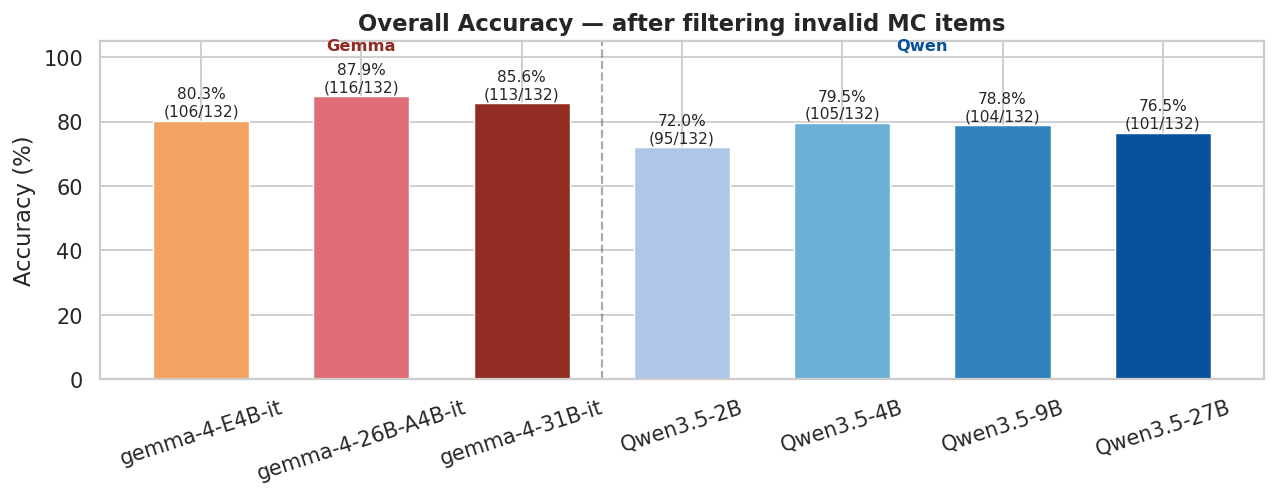

             model  accuracy  n_correct  n_total
    gemma-4-E4B-it 80.303030        106      132
gemma-4-26B-A4B-it 87.878788        116      132
    gemma-4-31B-it 85.606061        113      132
        Qwen3.5-2B 71.969697         95      132
        Qwen3.5-4B 79.545455        105      132
        Qwen3.5-9B 78.787879        104      132
       Qwen3.5-27B 76.515152        101      132


In [4]:
# Add shared columns used throughout
TAX_SHORT = {'cross_turn_entity_tracking': 'CTET', 'temporal_causal_reasoning': 'TCR'}
df['tax_short'] = df['taxonomy'].map(TAX_SHORT).fillna(df['taxonomy'])
df['family']    = df['model'].apply(lambda m: 'Qwen' if 'Qwen' in m else 'Gemma')

acc = (
    df.groupby('model')['correct']
    .agg(accuracy='mean', n_correct='sum', n_total='count')
    .assign(accuracy=lambda x: x['accuracy'] * 100)
    .reindex(MODEL_ORDER)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [MODEL_COLORS[m] for m in acc['model']]
bars = ax.bar(acc['model'], acc['accuracy'], color=colors, width=0.6, edgecolor='white', linewidth=0.8)
for bar, (_, row) in zip(bars, acc.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f"{row['accuracy']:.1f}%\n({int(row['n_correct'])}/{int(row['n_total'])})",
            ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Accuracy — after filtering invalid MC items', fontweight='bold')
ax.tick_params(axis='x', rotation=18)

# Family separator line
ax.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax.text(1.0,  102, 'Gemma', ha='center', fontsize=9, color='#922b21', fontweight='bold')
ax.text(4.5, 102, 'Qwen',  ha='center', fontsize=9, color='#08519c', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_overall_accuracy.png', bbox_inches='tight')
plt.show()
print(acc[['model','accuracy','n_correct','n_total']].to_string(index=False))

## 3. Failure Mode Breakdown

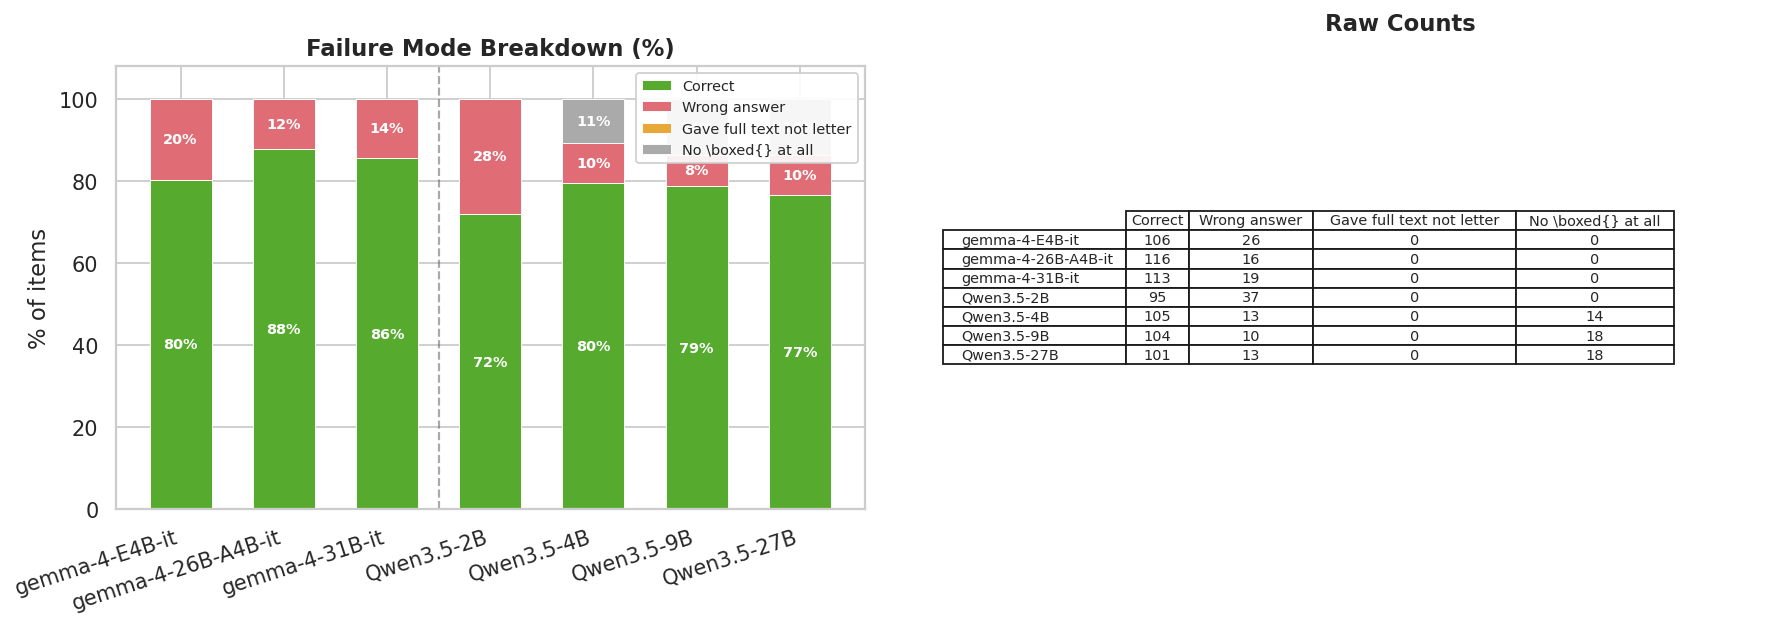

In [5]:
MODES = ['correct', 'wrong_answer', 'option_text_not_letter', 'format_failure']
MODE_COLORS = {'correct': '#56ab2f', 'wrong_answer': '#e06c75',
               'option_text_not_letter': '#e8a838', 'format_failure': '#aaa'}
MODE_LABELS = {'correct': 'Correct', 'wrong_answer': 'Wrong answer',
               'option_text_not_letter': 'Gave full text not letter',
               'format_failure': 'No \\boxed{} at all'}

mode_counts = (
    df.groupby(['model', 'failure_mode']).size()
    .unstack('failure_mode').reindex(MODEL_ORDER).fillna(0)
)
mode_pct = (mode_counts.div(mode_counts.sum(axis=1), axis=0) * 100).reindex(columns=MODES, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bottoms = np.zeros(len(mode_pct))
x = np.arange(len(mode_pct))
for mode in MODES:
    vals = mode_pct[mode].values
    ax.bar(x, vals, bottom=bottoms, label=MODE_LABELS[mode],
           color=MODE_COLORS[mode], width=0.6, edgecolor='white', linewidth=0.5)
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 5:
            ax.text(xi, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottoms += vals
ax.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(mode_pct.index, rotation=18, ha='right')
ax.set_ylabel('% of items'); ax.set_ylim(0, 108)
ax.set_title('Failure Mode Breakdown (%)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

ax2 = axes[1]
ax2.axis('off')
table_data = mode_counts.reindex(columns=MODES, fill_value=0).astype(int)
table_data.columns = [MODE_LABELS[m] for m in MODES]
t = ax2.table(cellText=table_data.values, rowLabels=table_data.index,
              colLabels=table_data.columns, cellLoc='center', loc='center')
t.auto_set_font_size(False); t.set_fontsize(8)
t.auto_set_column_width(col=list(range(len(table_data.columns))))
ax2.set_title('Raw Counts', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('fig_failure_modes.png', bbox_inches='tight')
plt.show()

## 4. Accuracy by Taxonomy

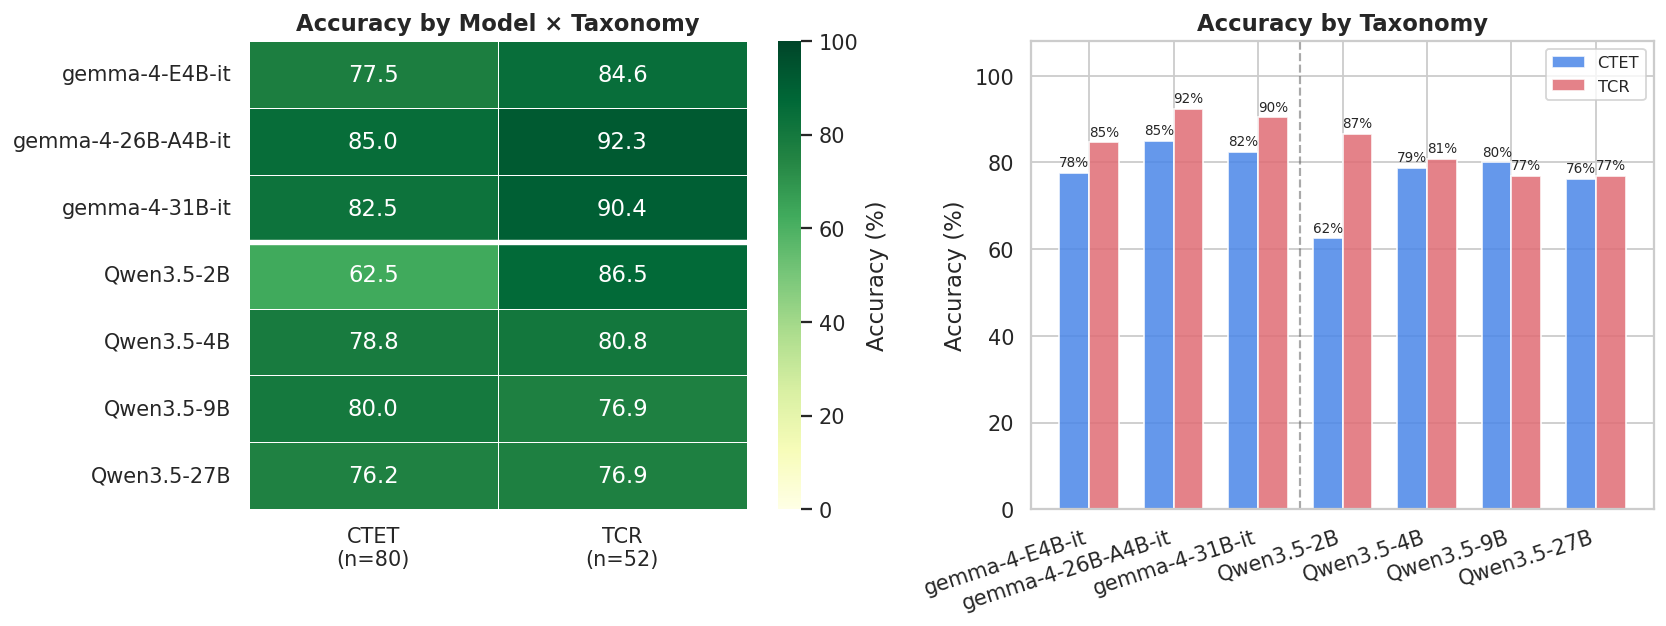

tax_short           CTET   TCR
model                         
gemma-4-E4B-it      77.5  84.6
gemma-4-26B-A4B-it  85.0  92.3
gemma-4-31B-it      82.5  90.4
Qwen3.5-2B          62.5  86.5
Qwen3.5-4B          78.8  80.8
Qwen3.5-9B          80.0  76.9
Qwen3.5-27B         76.2  76.9


In [6]:
tax_acc = (df.groupby(['model', 'tax_short'])['correct'].mean() * 100).unstack('tax_short').reindex(MODEL_ORDER)
tax_n   =  df[df['model']==df['model'].iloc[0]].groupby('tax_short').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
col_labels = {c: f'{c}\n(n={tax_n.get(c,0)})' for c in tax_acc.columns}
sns.heatmap(tax_acc.rename(columns=col_labels), annot=True, fmt='.1f', cmap='YlGn',
            ax=ax, vmin=0, vmax=100, linewidths=0.5, cbar_kws={'label': 'Accuracy (%)'})
# Family separator
ax.axhline(3, color='white', linewidth=3)
ax.set_title('Accuracy by Model × Taxonomy', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

ax2 = axes[1]
x = np.arange(len(MODEL_ORDER)); w = 0.35
for i, (tax, col) in enumerate(zip(list(tax_acc.columns), ['#4a86e8', '#e06c75'])):
    vals = tax_acc[tax].values
    bars = ax2.bar(x + (i-0.5)*w, vals, w, label=tax, color=col, edgecolor='white', alpha=0.85)
    ax2.bar_label(bars, fmt='%.0f%%', fontsize=7.5, padding=2)
ax2.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
ax2.set_ylabel('Accuracy (%)'); ax2.set_ylim(0, 108)
ax2.set_title('Accuracy by Taxonomy', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_taxonomy.png', bbox_inches='tight')
plt.show()
print(tax_acc.round(1))

## 5. Accuracy by Question Type

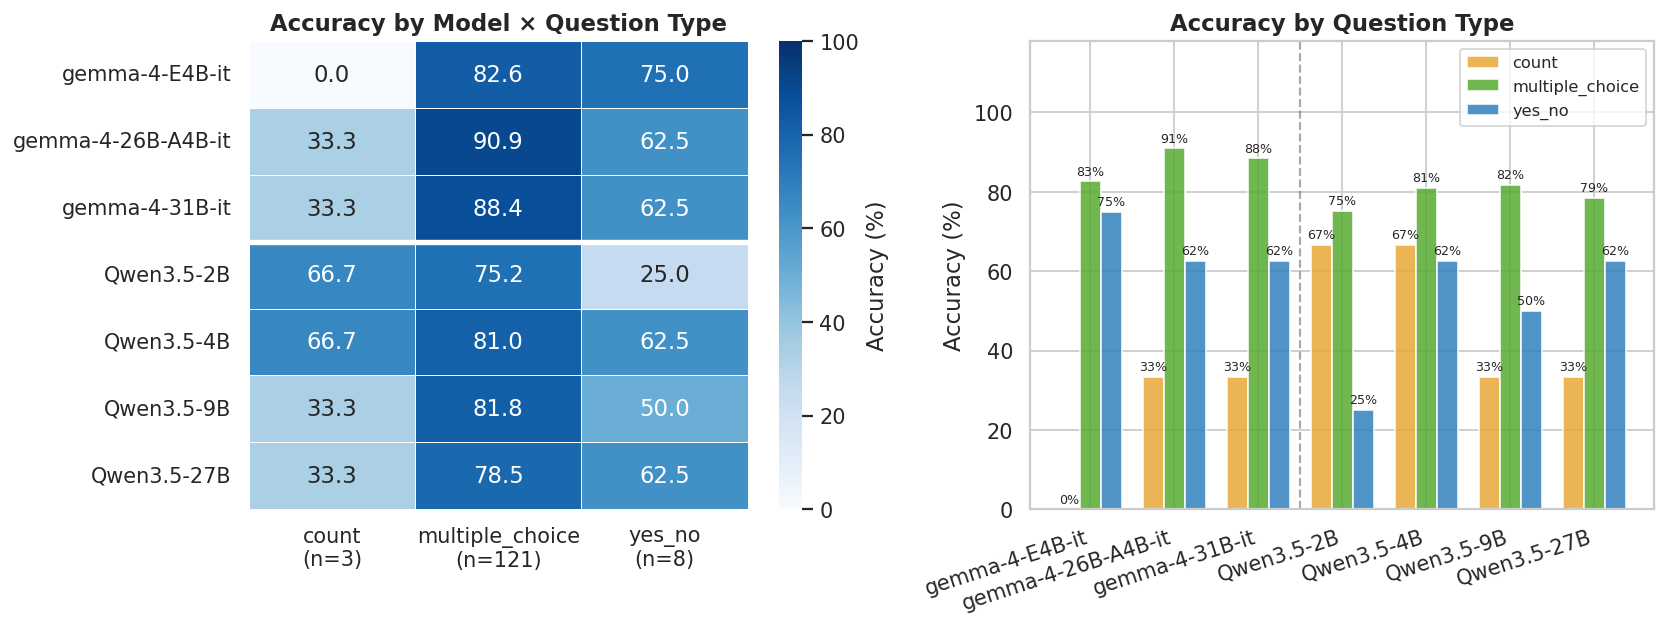

In [7]:
qt_acc = (df.groupby(['model', 'question_type'])['correct'].mean() * 100).unstack('question_type').reindex(MODEL_ORDER)
qt_n   =  df[df['model']==df['model'].iloc[0]].groupby('question_type').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
col_labels = {c: f'{c}\n(n={qt_n.get(c,0)})' for c in qt_acc.columns}
sns.heatmap(qt_acc.rename(columns=col_labels), annot=True, fmt='.1f', cmap='Blues',
            ax=ax, vmin=0, vmax=100, linewidths=0.5, cbar_kws={'label': 'Accuracy (%)'})
ax.axhline(3, color='white', linewidth=3)
ax.set_title('Accuracy by Model × Question Type', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

ax2 = axes[1]
qt_list = sorted(qt_acc.columns)
qt_colors = ['#e8a838', '#56ab2f', '#3182bd']
x = np.arange(len(MODEL_ORDER)); w = 0.25
for i, (qt, col) in enumerate(zip(qt_list, qt_colors)):
    if qt not in qt_acc.columns: continue
    bars = ax2.bar(x + (i-1)*w, qt_acc[qt].values, w, label=qt, color=col, edgecolor='white', alpha=0.85)
    ax2.bar_label(bars, fmt='%.0f%%', fontsize=7, padding=2)
ax2.axvline(2.5, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(MODEL_ORDER, rotation=18, ha='right')
ax2.set_ylabel('Accuracy (%)'); ax2.set_ylim(0, 118)
ax2.set_title('Accuracy by Question Type', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_question_type.png', bbox_inches='tight')
plt.show()

## 6. Scaling Curves — Qwen & Gemma

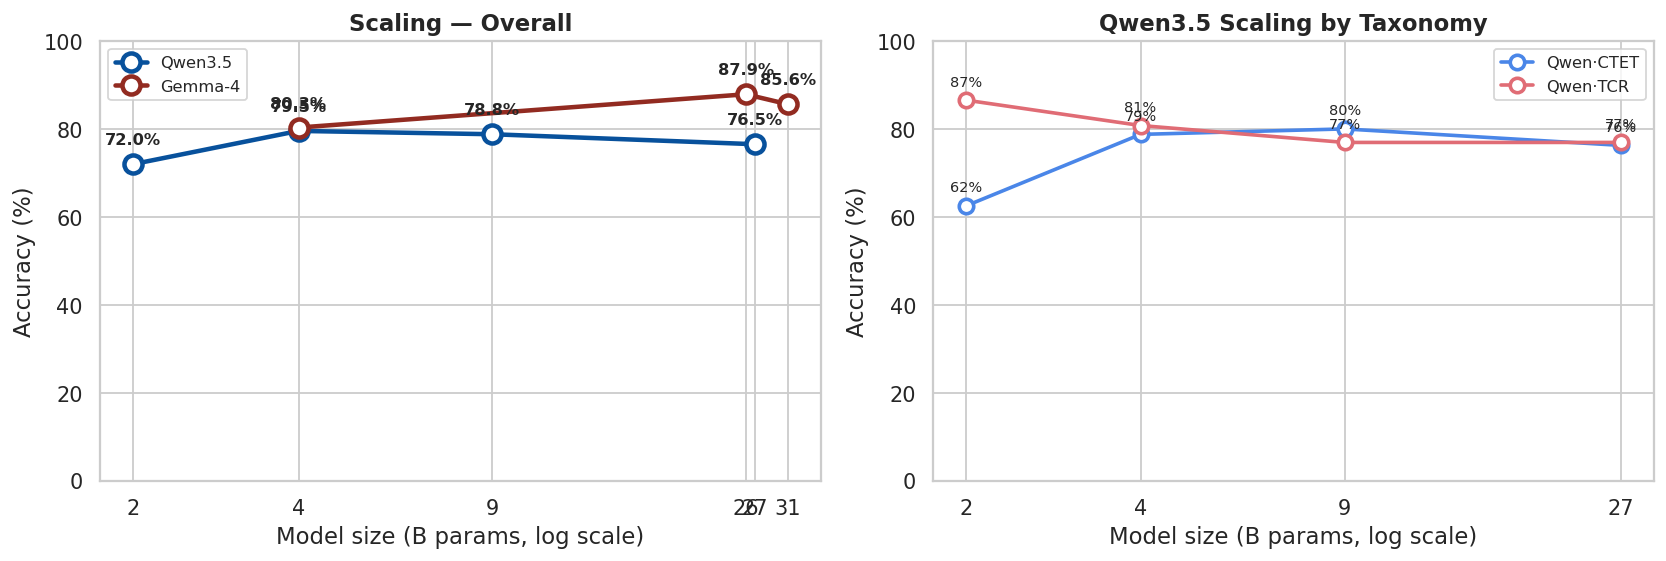

In [8]:
QWEN_SIZES  = {'Qwen3.5-2B': 2, 'Qwen3.5-4B': 4, 'Qwen3.5-9B': 9, 'Qwen3.5-27B': 27}
GEMMA_SIZES = {'gemma-4-E4B-it': 4, 'gemma-4-26B-A4B-it': 26, 'gemma-4-31B-it': 31}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

def plot_scaling(ax, size_map, color, label, tax_colors=None):
    sub = df[df['model'].isin(size_map)].copy()
    sub['params_b'] = sub['model'].map(size_map)
    overall = sub.groupby('params_b')['correct'].mean().reset_index().sort_values('params_b')
    overall['acc'] = overall['correct'] * 100
    ax.plot(overall['params_b'], overall['acc'], 'o-', color=color, linewidth=2.5,
            markersize=10, markerfacecolor='white', markeredgewidth=2.5, label=label)
    for _, row in overall.iterrows():
        ax.annotate(f"{row['acc']:.1f}%", (row['params_b'], row['acc']),
                    textcoords='offset points', xytext=(0, 11), ha='center', fontsize=9, fontweight='bold')

# Left: both families overall
ax = axes[0]
plot_scaling(ax, QWEN_SIZES,  '#08519c', 'Qwen3.5')
plot_scaling(ax, GEMMA_SIZES, '#922b21', 'Gemma-4')
ax.set_xscale('log'); ax.set_xticks([2,4,9,26,27,31])
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel('Model size (B params, log scale)'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Scaling — Overall', fontweight='bold'); ax.set_ylim(0, 100); ax.legend(fontsize=9)

# Right: Qwen by taxonomy
ax2 = axes[1]
qwen = df[df['model'].isin(QWEN_SIZES)].copy()
qwen['params_b'] = qwen['model'].map(QWEN_SIZES)
for tax, col in [('CTET', '#4a86e8'), ('TCR', '#e06c75')]:
    g = qwen[qwen['tax_short']==tax].groupby('params_b')['correct'].mean().reset_index().sort_values('params_b')
    g['acc'] = g['correct'] * 100
    ax2.plot(g['params_b'], g['acc'], 'o-', label=f'Qwen·{tax}', color=col,
             linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
    for _, row in g.iterrows():
        ax2.annotate(f"{row['acc']:.0f}%", (row['params_b'], row['acc']),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax2.set_xscale('log'); ax2.set_xticks([2,4,9,27])
ax2.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax2.set_xlabel('Model size (B params, log scale)'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Qwen3.5 Scaling by Taxonomy', fontweight='bold')
ax2.set_ylim(0, 100); ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_scaling.png', bbox_inches='tight')
plt.show()

## 7. Item-Level Difficulty

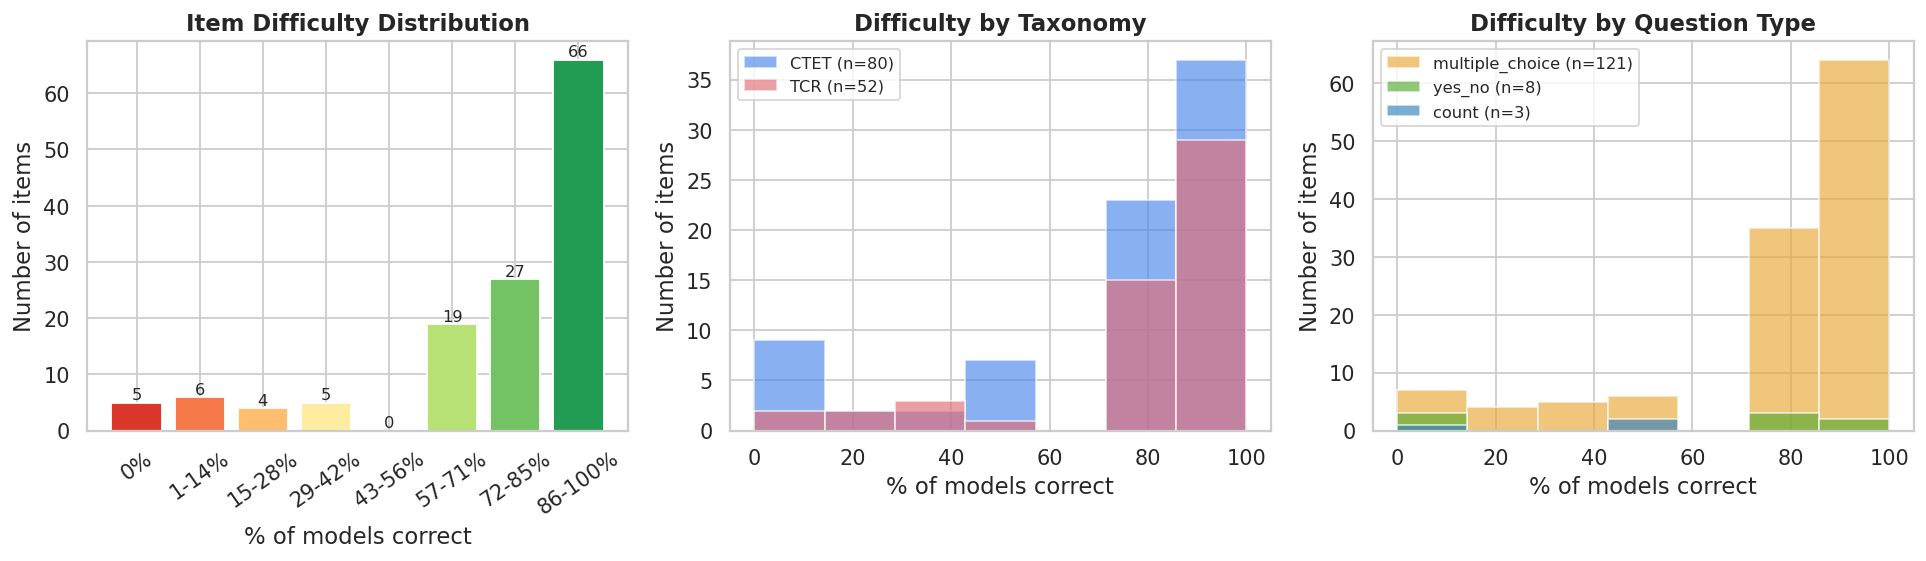

All models correct :  66 (50.0%)
No model correct   :   5 (3.8%)
Mixed              :  61 (46.2%)
Mean item accuracy : 80.1%


In [9]:
item_acc  = df.groupby('idx')['correct'].mean() * 100
item_meta = (
    df[df['model'] == df['model'].iloc[0]]
    [['idx','taxonomy','tax_short','question_type','scenario_title','question','ground_truth']]
    .set_index('idx')
)
item_df = item_meta.join(item_acc.rename('pct_correct'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
bins = [0, 1, 15, 29, 43, 57, 72, 86, 100.01]
hist_vals, _ = np.histogram(item_df['pct_correct'], bins=bins)
labels = ['0%','1-14%','15-28%','29-42%','43-56%','57-71%','72-85%','86-100%']
palette = sns.color_palette('RdYlGn', len(labels))
bars = ax.bar(labels, hist_vals, color=palette, edgecolor='white')
ax.bar_label(bars, fontsize=9)
ax.set_xlabel('% of models correct'); ax.set_ylabel('Number of items')
ax.set_title('Item Difficulty Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=35)

ax2 = axes[1]
for tax, col in [('CTET','#4a86e8'),('TCR','#e06c75')]:
    sub = item_df[item_df['tax_short']==tax]['pct_correct']
    ax2.hist(sub, bins=7, range=(0,100), alpha=0.65, color=col, label=f'{tax} (n={len(sub)})', edgecolor='white')
ax2.set_xlabel('% of models correct'); ax2.set_ylabel('Number of items')
ax2.set_title('Difficulty by Taxonomy', fontweight='bold'); ax2.legend(fontsize=9)

ax3 = axes[2]
for qt, col in [('multiple_choice','#e8a838'),('yes_no','#56ab2f'),('count','#3182bd')]:
    sub = item_df[item_df['question_type']==qt]['pct_correct']
    if len(sub):
        ax3.hist(sub, bins=7, range=(0,100), alpha=0.65, color=col, label=f'{qt} (n={len(sub)})', edgecolor='white')
ax3.set_xlabel('% of models correct'); ax3.set_ylabel('Number of items')
ax3.set_title('Difficulty by Question Type', fontweight='bold'); ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_item_difficulty.png', bbox_inches='tight')
plt.show()

easy = item_df[item_df['pct_correct'] == 100]
hard = item_df[item_df['pct_correct'] == 0]
med  = item_df[(item_df['pct_correct'] > 0) & (item_df['pct_correct'] < 100)]
print(f'All models correct : {len(easy):3d} ({len(easy)/len(item_df)*100:.1f}%)')
print(f'No model correct   : {len(hard):3d} ({len(hard)/len(item_df)*100:.1f}%)')
print(f'Mixed              : {len(med):3d} ({len(med)/len(item_df)*100:.1f}%)')
print(f'Mean item accuracy : {item_df["pct_correct"].mean():.1f}%')

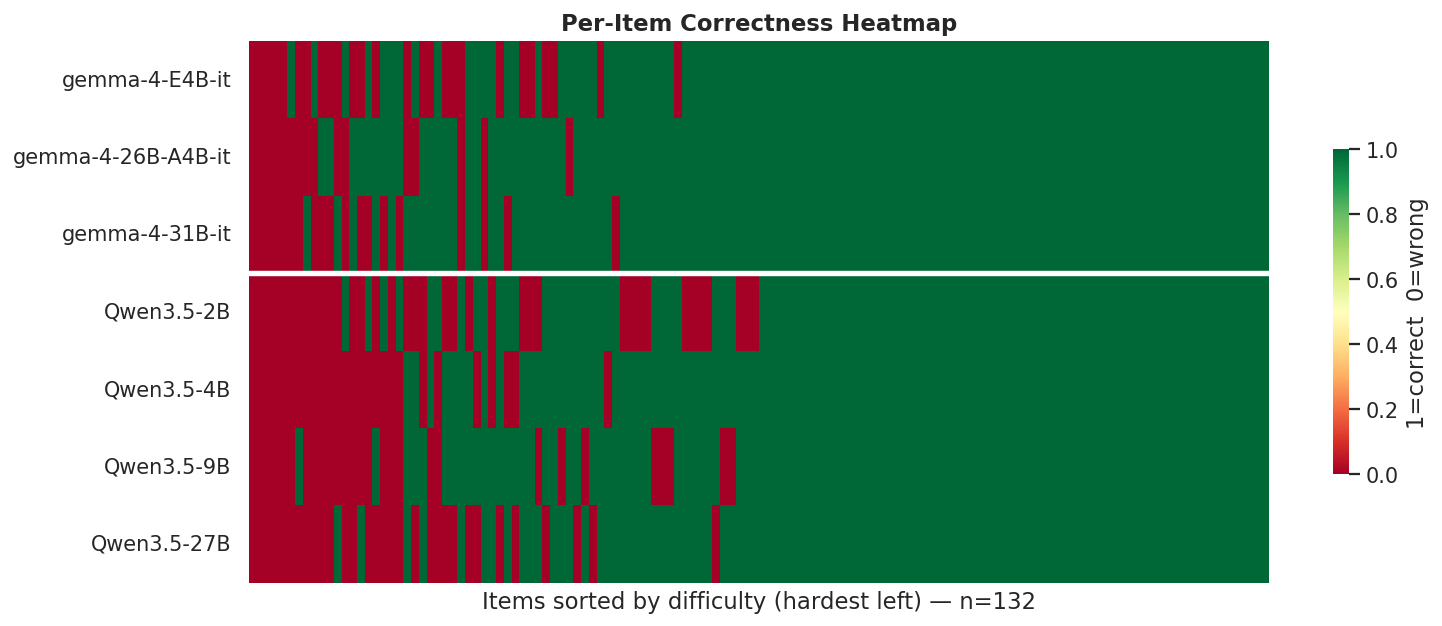

In [10]:
# Per-item heatmap
item_model = df.pivot_table(index='idx', columns='model', values='correct')[MODEL_ORDER]
item_model = item_model.loc[item_model.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(item_model.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=False, yticklabels=True, linewidths=0,
            cbar_kws={'label': '1=correct  0=wrong', 'shrink': 0.6})
# Family separator line
ax.axhline(3, color='white', linewidth=3)
ax.set_xlabel(f'Items sorted by difficulty (hardest left) — n={len(item_model)}')
ax.set_ylabel('')
ax.set_title('Per-Item Correctness Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_item_heatmap.png', bbox_inches='tight')
plt.show()

In [11]:
print('=== Items no model solved ===\n')
for idx, row in hard.iterrows():
    print(f'  idx={idx}  [{row["tax_short"]}] [{row["question_type"]}]  GT={row["ground_truth"]!r}')
    print(f'  Title: {row["scenario_title"]}')
    print(f'  Q: {row["question"][:160]}')
    print()

=== Items no model solved ===

  idx=21  [CTET] [yes_no]  GT='no'
  Title: The Sliding Star Puzzle
  Q: Wait, I might have miscounted the moves. Looking at the whole history, was the Star ever adjacent to the empty space in the third image shown?

  idx=80  [CTET] [multiple_choice]  GT='c'
  Title: Red Sedan Overtake
  Q: Based on the last image where the red sedan finished passing, where is it positioned relative to the bus? A) Still directly behind the bus B) On the left side o

  idx=85  [CTET] [yes_no]  GT='yes'
  Title: The Disappearing Mug
  Q: Looking at the last photo alone, is the mug with the blue handle still there?

  idx=162  [TCR] [count]  GT='3'
  Title: Origami Collapse and Distortion
  Q: Looking at the final state of the blue and red units, how many specific major creases were distorted by the collapse?

  idx=163  [TCR] [multiple_choice]  GT='d'
  Title: Origami Waterbomb Causal Chain
  Q: Based on the sequence of changes I showed you, did the initial spiral twist ca

## 8. Cross-Model Agreement

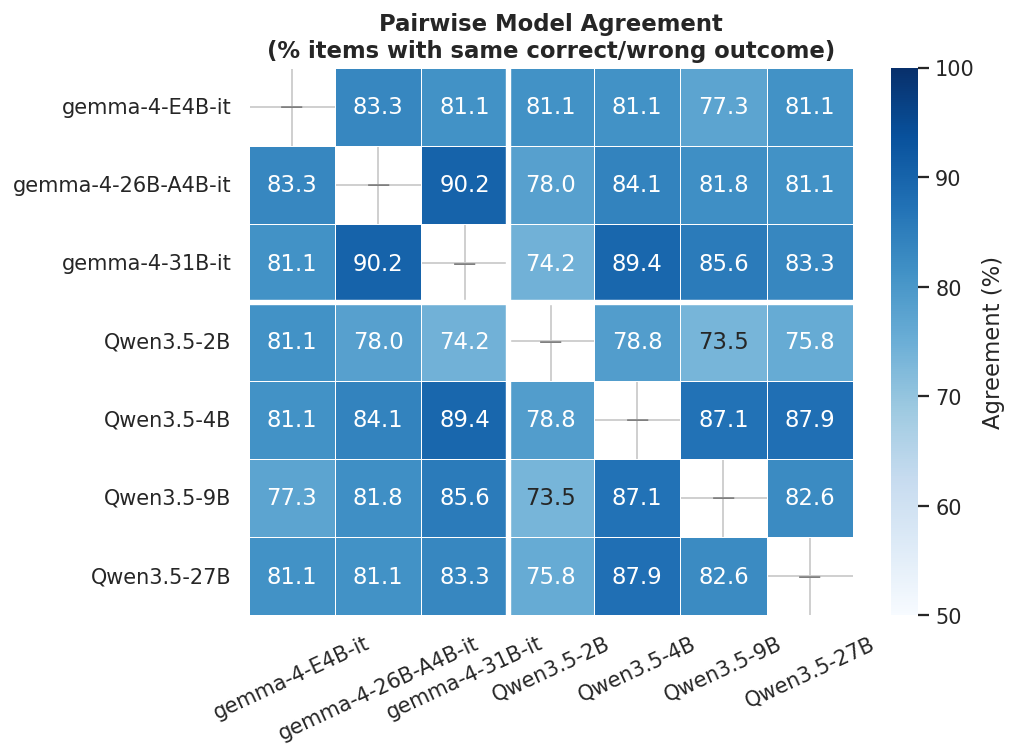

In [12]:
correct_matrix = df.pivot_table(index='idx', columns='model', values='correct')[MODEL_ORDER]

n = len(MODEL_ORDER)
agree = np.zeros((n, n))
for i, m1 in enumerate(MODEL_ORDER):
    for j, m2 in enumerate(MODEL_ORDER):
        agree[i, j] = (correct_matrix[m1] == correct_matrix[m2]).mean() * 100
agree_df = pd.DataFrame(agree, index=MODEL_ORDER, columns=MODEL_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.eye(n, dtype=bool)
sns.heatmap(agree_df, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            mask=mask, vmin=50, vmax=100, linewidths=0.5,
            cbar_kws={'label': 'Agreement (%)'})
for i in range(n):
    ax.text(i+0.5, i+0.5, '—', ha='center', va='center', fontsize=13, color='gray')
# Family separator
ax.axhline(3, color='white', linewidth=3); ax.axvline(3, color='white', linewidth=3)
ax.set_title('Pairwise Model Agreement\n(% items with same correct/wrong outcome)', fontweight='bold')
ax.tick_params(axis='x', rotation=25); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('fig_agreement.png', bbox_inches='tight')
plt.show()

In [13]:
item_std = correct_matrix.std(axis=1).rename('std')
controversial = item_std.nlargest(10).to_frame().join(item_meta)

# Pivot predictions so we can show what each model actually answered
pred_matrix = df.pivot_table(index='idx', columns='model', values='prediction', aggfunc='first')[MODEL_ORDER]

short = {m: m.replace('gemma-4-','G-').replace('Qwen3.5-','Q-') for m in MODEL_ORDER}

print('=== Most Controversial Items (models disagree most) ===\n')
for idx, row in controversial.iterrows():
    print(f'idx={idx}  [{row["tax_short"]}] [{row["question_type"]}]  GT={row["ground_truth"]!r}  std={row["std"]:.2f}')
    print(f'  Title  : {row["scenario_title"]}')
    print(f'  Q      : {row["question"][:150]}')
    for m in MODEL_ORDER:
        pred = pred_matrix.loc[idx, m]
        correct = correct_matrix.loc[idx, m]
        mark = '\u2713' if correct == 1 else '\u2717'
        print(f'  {mark} {short[m]:15s} pred={str(pred)!r}')
    print()


=== Most Controversial Items (models disagree most) ===

idx=22  [CTET] [multiple_choice]  GT='b'  std=0.53
  Title  : The Leaning Jenga Tower
  Q      : How many blocks are currently physically touching and supporting the green smiley block? A) 1 B) 2 C) 3 D) 0
  ✓ G-E4B-it        pred='b'
  ✓ G-26B-A4B-it    pred='b'
  ✗ G-31B-it        pred='a'
  ✓ Q-2B            pred='b'
  ✗ Q-4B            pred='c'
  ✗ Q-9B            pred='nan'
  ✗ Q-27B           pred='d'

idx=36  [CTET] [count]  GT='2'  std=0.53
  Title  : Saint Jude Foxing and Cracks
  Q      : Back to Saint Jude. How many new cracks have appeared right next to that specific spot of foxing?
  ✗ G-E4B-it        pred='1'
  ✗ G-26B-A4B-it    pred='3'
  ✗ G-31B-it        pred='4'
  ✓ Q-2B            pred='2'
  ✓ Q-4B            pred='2'
  ✓ Q-9B            pred='2'
  ✓ Q-27B           pred='2'

idx=37  [CTET] [multiple_choice]  GT='b'  std=0.53
  Title  : The Red Lion Facade Tracking
  Q      : Based on the jagged break in the le

## 9. Model Family Comparison — Gemma vs Qwen

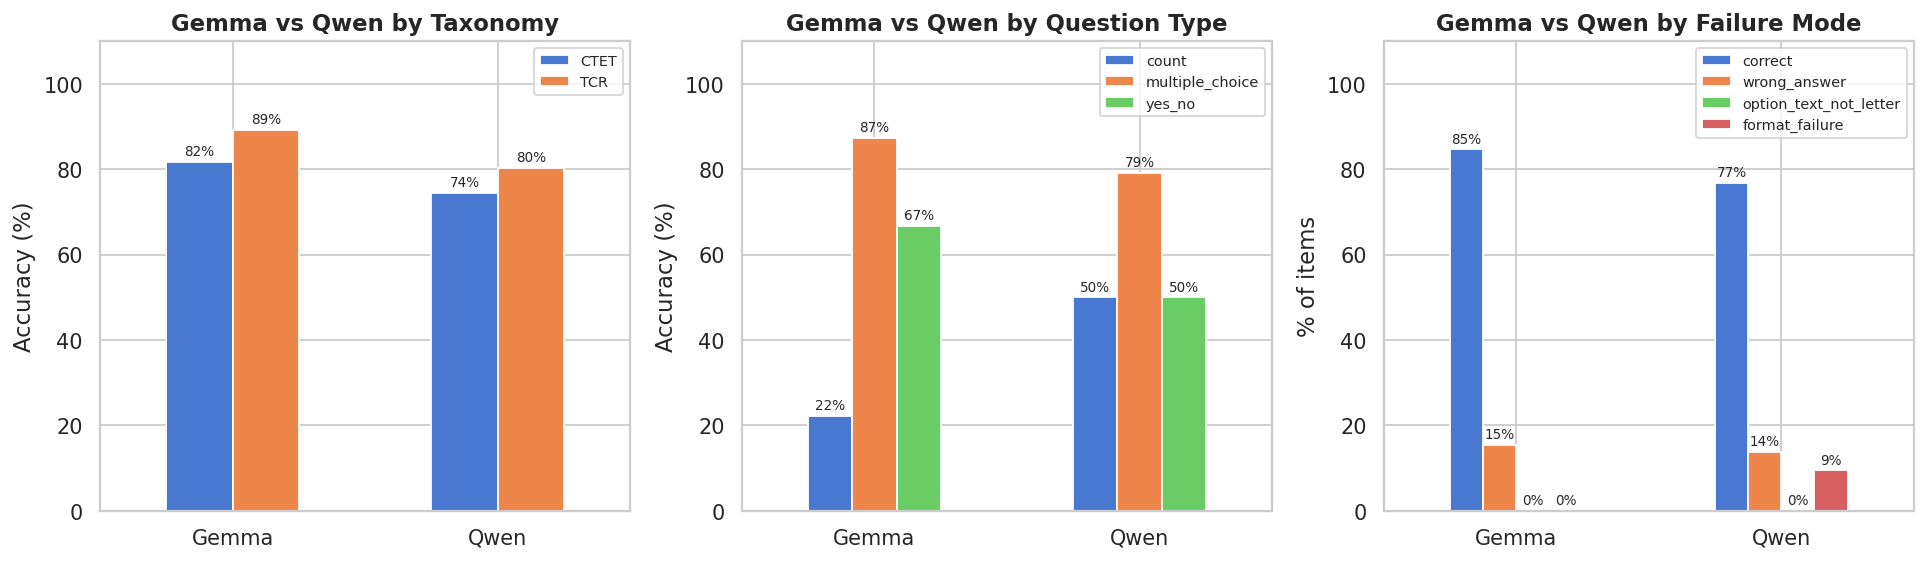

In [14]:
MODES = ['correct', 'wrong_answer', 'option_text_not_letter', 'format_failure']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, dim, title, ylabel in zip(
    axes,
    ['tax_short', 'question_type', 'failure_mode'],
    ['by Taxonomy', 'by Question Type', 'by Failure Mode'],
    ['Accuracy (%)', 'Accuracy (%)', '% of items'],
):
    if dim == 'failure_mode':
        grp = (df.groupby(['family', dim]).size() /
               df.groupby('family').size()).unstack(dim).fillna(0) * 100
        grp = grp.reindex(columns=MODES, fill_value=0)
    else:
        grp = (df.groupby(['family', dim])['correct'].mean() * 100).unstack(dim)
    grp.plot(kind='bar', ax=ax, width=0.5, edgecolor='white')
    ax.set_title(f'Gemma vs Qwen {title}', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(ylabel)
    ax.set_ylim(0, 110); ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8, loc='upper right')
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.0f%%', fontsize=7.5, padding=2)

plt.tight_layout()
plt.savefig('fig_family_comparison.png', bbox_inches='tight')
plt.show()

## 10. Full Summary Table

In [15]:
def pct_str(sub):
    n = len(sub); c = int(sub['correct'].sum())
    return f'{c/n*100:.1f}% ({c}/{n})' if n else 'N/A'

rows = []
for model in MODEL_ORDER:
    m = df[df['model'] == model]
    fm = m['failure_mode'].value_counts(normalize=True).mul(100)
    rows.append({
        'Model':        model,
        'Family':       'Gemma' if 'gemma' in model else 'Qwen',
        'Overall':      pct_str(m),
        'MC':           pct_str(m[m['question_type']=='multiple_choice']),
        'Yes/No':       pct_str(m[m['question_type']=='yes_no']),
        'Count':        pct_str(m[m['question_type']=='count']),
        'CTET':         pct_str(m[m['tax_short']=='CTET']),
        'TCR':          pct_str(m[m['tax_short']=='TCR']),
        'No-box%':      f"{fm.get('format_failure',0):.1f}%",
        'Opt-text%':    f"{fm.get('option_text_not_letter',0):.1f}%",
    })

summary = pd.DataFrame(rows).set_index('Model')
pd.set_option('display.max_colwidth', 22)
summary

,Family,Overall,MC,Yes/No,Count,CTET,TCR,No-box%,Opt-text%
Model,,,,,,,,,
gemma-4-E4B-it,Gemma,80.3% (106/132),82.6% (100/121),75.0% (6/8),0.0% (0/3),77.5% (62/80),84.6% (44/52),0.0%,0.0%
gemma-4-26B-A4B-it,Gemma,87.9% (116/132),90.9% (110/121),62.5% (5/8),33.3% (1/3),85.0% (68/80),92.3% (48/52),0.0%,0.0%
gemma-4-31B-it,Gemma,85.6% (113/132),88.4% (107/121),62.5% (5/8),33.3% (1/3),82.5% (66/80),90.4% (47/52),0.0%,0.0%
Qwen3.5-2B,Qwen,72.0% (95/132),75.2% (91/121),25.0% (2/8),66.7% (2/3),62.5% (50/80),86.5% (45/52),0.0%,0.0%
Qwen3.5-4B,Qwen,79.5% (105/132),81.0% (98/121),62.5% (5/8),66.7% (2/3),78.8% (63/80),80.8% (42/52),10.6%,0.0%
Qwen3.5-9B,Qwen,78.8% (104/132),81.8% (99/121),50.0% (4/8),33.3% (1/3),80.0% (64/80),76.9% (40/52),13.6%,0.0%
Qwen3.5-27B,Qwen,76.5% (101/132),78.5% (95/121),62.5% (5/8),33.3% (1/3),76.2% (61/80),76.9% (40/52),13.6%,0.0%
